# Marketing Incrementality Under Selection Bias

A causal inference project: *How robust are different measurement approaches under selection bias?*

Marketing performance is often measured using simple comparisons like conversion rates or attribution models. These approaches assume that users who see an ad are comparable to those who don’t.

In reality, that’s rarely true. Higher-intent users are often more likely to be exposed to marketing in the first place, introducing selection bias.

*This mirrors a common real-world scenario where marketing performance appears strong under attribution models, but true incremental impact is significantly lower when measured through controlled experiments.*

In this project, I simulate a dataset with a known underlying process and use it to test how different measurement approaches behave. 

🎯 The aim is to understand how well each method recovers the true treatment effect under different conditions.

**Approach**:

1. Create synthetic dataset - with selection bias and naive conversion comparison
2. Propensity score matching
3. Simulated a/b test
4. Business recommendation

### Executive Summary

**This project explores how different approaches to measuring marketing impact can lead to very different conclusions.**

Using a simulated dataset with built-in selection bias, a naive comparison suggests a ~2.0 percentage point uplift in conversion. However, this overstates the true incremental effect (~1.0pp), as higher-intent users are more likely to be exposed to the campaign.

Attempts to correct for this using propensity score matching produce inconsistent results (~5.3pp), highlighting the sensitivity of observational methods to modelling and matching assumptions. In contrast, a randomised A/B test provides an estimate (~1.1pp) close to the true effect.

The key takeaway is that correlation does not imply causation - and that controlled experiments are the most reliable way to measure incrementality and inform marketing investment decisions.

### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

## 1. Create synthetic dataset

In [2]:
cols = [
    "user_id",
    "age_group",
    "customer_type",
    "prior_sessions",
    "prior_purchases",
    "email_engaged",
    "baseline_propensity",
    "treatment_probability",
    "treatment",
    "conversion_probability",
    "conversion"
]

df = pd.DataFrame(columns=cols)

df.columns

Index(['user_id', 'age_group', 'customer_type', 'prior_sessions',
       'prior_purchases', 'email_engaged', 'baseline_propensity',
       'treatment_probability', 'treatment', 'conversion_probability',
       'conversion'],
      dtype='str')

In [3]:
# Set random seed for reproducibility
np.random.seed(42)

N = 100_000

# Define user features (lam = average behaviour)
df["user_id"] = np.arange(1, N + 1)
df["age_group"] = np.random.choice(["18-25", "26-35", "36-45", "46-55", "56+"], size=N, p=[0.2, 0.3, 0.25, 0.15, 0.1])
df["customer_type"] = np.random.choice(["new", "returning"], size=N, p=[0.4, 0.6])
df["prior_sessions"] = np.random.poisson(lam=5, size=N)
df["prior_purchases"] = np.random.binomial(n=5, p=0.2)
df["email_engaged"] = np.random.binomial(n=1, p=0.3, size=N)

# =======================================================
# Define baseline propensity to convert based on features
# =======================================================

# WEIGHTS FOR CONVERSION PROBABILITY:
# returning customer     +0.5
# prior purchases        +0.5 each
# email engaged          +0.8
# prior sessions         +0.15 each

# --- Map age groups and customer types to numeric values for propensity calculation ---

# Assume age groups have a certain influence on conversion propensity
# Assume older age groups are more likely than average to convert, younger less likely
age_group_mapping = {
    "18-25": -0.2,
    "26-35": 0.0,
    "36-45": 0.1,
    "46-55": 0.2,
    "56+": 0.3
}

# Assume returning customers are more likely than average to convert, new customers less likely
customer_type_mapping = {
    "new": -0.3,
    "returning": 0.5
}

# Assign probability contributions based on user features
df["baseline_logit"] = (
    -2 +
    df["age_group"].map(age_group_mapping) +
    df["customer_type"].map(customer_type_mapping) +
    df["prior_purchases"] * 0.5 +
    df["email_engaged"] * 0.8 +
    df["prior_sessions"] * 0.15
)

# Convert logit to probability using logistic function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

df["baseline_propensity"] = sigmoid(df["baseline_logit"])

df.head()

,user_id,age_group,customer_type,prior_sessions,prior_purchases,email_engaged,baseline_propensity,treatment_probability,treatment,conversion_probability,conversion,baseline_logit
0,1,26-35,returning,3,0,1,0.437823,NaN,NaN,NaN,NaN,-0.25
1,2,56+,returning,5,0,1,0.586618,NaN,NaN,NaN,NaN,0.35
2,3,36-45,new,2,0,1,0.249740,NaN,NaN,NaN,NaN,-1.10
3,4,36-45,returning,5,0,0,0.342990,NaN,NaN,NaN,NaN,-0.65
4,5,18-25,new,6,0,0,0.167982,NaN,NaN,NaN,NaN,-1.60


In [4]:
# --- Treatment Assignment ---

# Define probability of customer seeing ad campaign (treatment assignment)
# Assume treatment assignment is influenced by baseline propensity
# e.g. more likely to target users with higher propensity
df["treatment_probability"] = 0.2 + 0.5 * sigmoid(df["baseline_propensity"] - 0.5)  # Base 20% chance, increases with higher propensity

# Define treatment assignment based on probability
df["treatment"] = np.random.binomial(n=1, p=df["treatment_probability"])


# --- Treatment Effect ---
# Define causal effect of treatment on conversion probability
# Assume treatment increases conversion probability by a fixed amount (true effect)

TRUE_EFFECT = 0.01  # True average treatment effect (1 ppt increase)

# Generate conversion probability (between 0 and 1)
df["conversion_probability"] = (
    df["baseline_propensity"] +
    df["treatment"] * TRUE_EFFECT
).clip(0, 1)

df.head()

,user_id,age_group,customer_type,prior_sessions,prior_purchases,email_engaged,baseline_propensity,treatment_probability,treatment,conversion_probability,conversion,baseline_logit
0,1,26-35,returning,3,0,1,0.437823,0.442230,0,0.437823,NaN,-0.25
1,2,56+,returning,5,0,1,0.586618,0.460820,1,0.596618,NaN,0.35
2,3,36-45,new,2,0,1,0.249740,0.418880,1,0.259740,NaN,-1.10
3,4,36-45,returning,5,0,0,0.342990,0.430414,0,0.342990,NaN,-0.65
4,5,18-25,new,6,0,0,0.167982,0.408875,0,0.167982,NaN,-1.60


In [5]:
# Generate conversion outcome based on conversion probability
df["conversion"] = np.random.binomial(n=1, p=df["conversion_probability"])

df["conversion"].head(10)

0    0
1    1
2    0
3    0
4    0
5    0
6    0
7    0
8    1
9    1
Name: conversion, dtype: int64

### 🧪 Checks

In [6]:
# Treated users should have higher baseline intent
df.groupby("treatment")["baseline_propensity"].mean()

treatment
0    0.325139
1    0.334245
Name: baseline_propensity, dtype: float64

In [7]:
# Treatment should look effective at a superficial level
df.groupby("treatment")["conversion"].mean()

treatment
0    0.322978
1    0.342734
Name: conversion, dtype: float64

In [8]:
# Compare naive lift to true lift
treated = df[df["treatment"] == 1]["conversion"].mean()
control = df[df["treatment"] == 0]["conversion"].mean()

naive_lift = treated - control
true_lift = TRUE_EFFECT

print(f"Naive Lift: {naive_lift:.4f}, True Lift: {true_lift:.4f}")

Naive Lift: 0.0198, True Lift: 0.0100


### 🙋‍♀️ Naive Lift Observations

The observed uplift (~3.6%) is higher than the true causal effect (1%), because treated users were already slightly more likely to convert.

## 2. Propensity Score

Propensity Score Matching (PSM) compares the behaviour of treated users to *similar* untreated users.

👉 Propensity Score = estimated probability of treatment, i.e. of user seeing campaign, *calculated from the data*.

In [9]:
# --- Predict Treatment from User Features ---

# Define features
features = ["age_group", "customer_type", "prior_sessions", "prior_purchases", "email_engaged"]

# Encode categorical features
X = pd.get_dummies(df[features], drop_first=True)

# Define target variable (treatment assignment)
y = df["treatment"]

# Fit logistic regression model
psm_model = LogisticRegression()
psm_model.fit(X, y)

# Predict treatment probabilities
df["propensity_score"] = psm_model.predict_proba(X)[:, 1]

In [10]:
df[["treatment_probability", "propensity_score"]].head()

,treatment_probability,propensity_score
0,0.442230,0.443902
1,0.460820,0.458544
2,0.418880,0.417672
3,0.430414,0.424763
4,0.408875,0.408829


In [11]:
# --- Match treated and control users based on propensity score ---
treated_users = df[df["treatment"] == 1].copy()
control_users = df[df["treatment"] == 0].copy()

# Fit nearest neighbors model on control users' propensity scores
nn = NearestNeighbors(n_neighbors=1)
nn.fit(control_users[["propensity_score"]])

distances, indices = nn.kneighbors(treated_users[["propensity_score"]])

# Get matched controls for treated users
matched_control_users = control_users.iloc[indices.flatten()].copy()

# Calculate conversion rates for treated users and matched controls
matched_control_conversion = matched_control_users["conversion"].mean()
treated_conversion = treated_users["conversion"].mean()

# Calculate PSM lift
psm_lift = treated_conversion - matched_control_conversion

print(f"Naive Lift: {naive_lift:.4f}")
print(f"PSM Estimated Lift: {psm_lift:.4f}")
print(f"True Lift: {TRUE_EFFECT:.4f}")

Naive Lift: 0.0198
PSM Estimated Lift: 0.0529
True Lift: 0.0100


### 🧪 Checks

In [12]:
print("Average propensity by treatment:")
print(df.groupby("treatment")["propensity_score"].mean())

print("\nAverage match distance:")
print(distances.mean())

Average propensity by treatment:
treatment
0    0.427811
1    0.428973
Name: propensity_score, dtype: float64

Average match distance:
4.301582188737244e-07


### 🙋‍♀️ PSM Observations

Propensity score matching offers a way to adjust for selection bias using observed data, but in this case it provides limited improvement. 

The similarity in propensity scores between treated and control users means that matching does not meaningfully change the comparison. This reinforces the risk of relying on observational methods alone when making marketing spend decisions.

## 3. Simulate A/B test

In a simulated a/b test, treatment is assigned randomly, not informed by baseline intent.

In [13]:
# Create df copy for A/B testing analysis
ab_df = df.copy()

# Assign treatment randomly
ab_df["treatment_ab"] = np.random.binomial(n=1, p=0.5, size=N)

ab_df.columns.to_list()

['user_id',
 'age_group',
 'customer_type',
 'prior_sessions',
 'prior_purchases',
 'email_engaged',
 'baseline_propensity',
 'treatment_probability',
 'treatment',
 'conversion_probability',
 'conversion',
 'baseline_logit',
 'propensity_score',
 'treatment_ab']

In [14]:
# Recalculate conversion rates for A/B test
# Conversion proba = baseline propensity + treatment effect (if in treatment group)
ab_df["conversion_proba_ab"] = (
    ab_df["baseline_propensity"] +
    ab_df["treatment_ab"] * TRUE_EFFECT
).clip(0, 1)

# Generate conversion outcome for A/B test
ab_df["conversion_outcome_ab"] = np.random.binomial(n=1, p=ab_df["conversion_proba_ab"], size=N)

In [15]:
ab_df.groupby("treatment_ab")["baseline_propensity"].mean()

treatment_ab
0    0.329099
1    0.328979
Name: baseline_propensity, dtype: float64

In [16]:
ab_df.groupby("treatment_ab")["conversion_outcome_ab"].mean()

treatment_ab
0    0.327899
1    0.338946
Name: conversion_outcome_ab, dtype: float64

In [17]:
treated = ab_df[ab_df["treatment_ab"] == 1]["conversion_outcome_ab"].mean()
control = ab_df[ab_df["treatment_ab"] == 0]["conversion_outcome_ab"].mean()

ab_lift = treated - control

print(f"Naive Lift: {naive_lift:.4f}")
print(f"PSM Estimated Lift: {psm_lift:.4f}")
print(f"A/B Lift: {ab_lift:.4f}")
print(f"True Lift: {TRUE_EFFECT:.4f}")

Naive Lift: 0.0198
PSM Estimated Lift: 0.0529
A/B Lift: 0.0110
True Lift: 0.0100


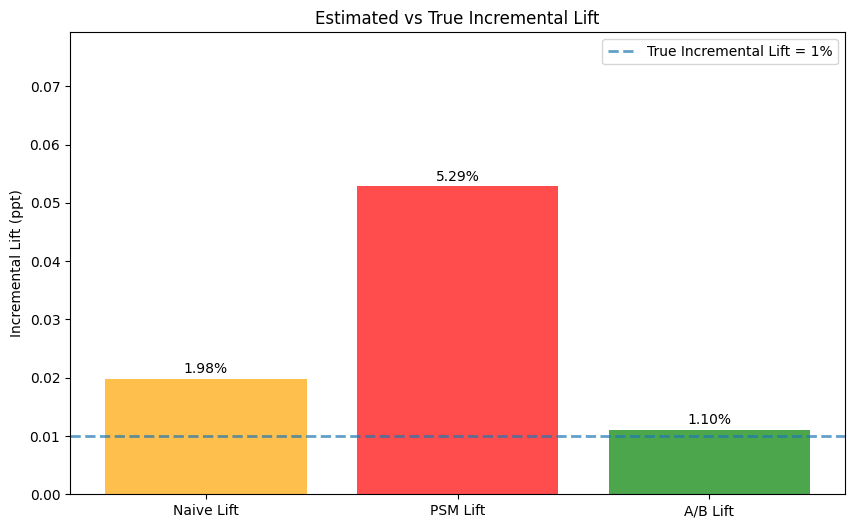

In [ ]:
# Plot lift estimates
plt.figure(figsize=(10, 6))
lifts = [naive_lift, psm_lift, ab_lift]
labels = ["Naive Lift", "PSM Lift", "A/B Lift"]
plt.bar(labels, lifts, color=["orange", "red", "green"], alpha=0.7)
plt.axhline(
    y=TRUE_EFFECT,
    linestyle='--',
    linewidth=2,
    alpha=0.7,
    label='True Incremental Lift = 1%'
)
plt.legend()
plt.ylabel("Incremental Lift (ppt)")
plt.title("Estimated vs True Incremental Lift")
plt.ylim(0, max(lifts) * 1.5)
for i, v in enumerate(lifts):
    plt.text(i, v + 0.001, f"{v:.2%}", ha='center')

plt.savefig("lift_comparison.png", bbox_inches='tight')

plt.show()

### 💡 Comparing approaches

- The naive estimate overstates the impact of the campaign due to selection bias. 
- Propensity score matching, while intended to correct for this bias, produces an even larger estimate in this case, highlighting its sensitivity to model specification and matching assumptions. 
- In contrast, the randomised A/B test provides an estimate close to the true effect, reinforcing its reliability for measuring incrementality.

This demonstrates that observational methods can not only fail to remove bias, but can also introduce additional distortion, whereas randomised experiments provide a more robust foundation for decision-making.

## 4. Business Recommendation

At first glance, the campaign looks like it’s performing well, with a ~2.0% lift in conversion using a simple comparison. However, this overstates the true impact due to higher-intent users being more likely to see the ads.

When we try to adjust for this using propensity score matching, the estimate becomes even more inflated (~5.3%), showing how sensitive observational methods can be to modelling and matching assumptions.

In contrast, the A/B test provides a much more reliable view, with an estimated lift of ~1.1%, closely aligning with the true incremental impact of ~1.0%.

**Recommendation**: Avoid scaling spend based on naive or observational metrics alone. Instead, use controlled holdout experiments to measure true incrementality, provide a clearer understanding of what’s driving incremental value and guide investment decisions with confidence.

#### *What does this mean in practice?*

For any campaign where we can control exposure, reserve a small random holdout group before launch. If direct user-level holdout is not feasible, use a geo or audience-level holdout to estimate incrementality.

While it may be tempting to run campaigns at full scale and analyse performance retrospectively, this approach makes it difficult to distinguish true impact from underlying demand. Introducing a small, controlled holdout group (e.g. 5–10% of the audience) provides a more reliable estimate of incremental value, while preserving the majority of short-term revenue.

## Conclusion

This analysis demonstrates the challenge of measuring marketing incrementality using observational data. A simple comparison of conversion rates suggests that the campaign is highly effective, but this is driven in part by selection bias - *users who are more likely to convert are also more likely to be exposed to the campaign*.

While propensity score matching is often used to adjust for this bias, the results here show that it can be highly sensitive to modelling choices and the underlying data structure. In this case, matching produced an even larger estimate than the naive approach, reinforcing that observational corrections are not inherently reliable.

In contrast, the simulated A/B test - where treatment is assigned randomly - provides an estimate that closely aligns with the true underlying effect. Although subject to some sampling variability, it offers a far more robust basis for understanding causal impact.

👉 Overall, this highlights an important principle: measuring marketing performance is not just about analysing data, but about designing the right experiments. Where possible, introducing controlled holdouts or randomised tests enables teams to move beyond correlation and make more confident, evidence-based decisions about where to invest.